In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import os

save_dir = "saved_charts"
os.makedirs(save_dir, exist_ok=True)

In [3]:
# Load data
df = pd.read_csv(r'D:\Data_D\TMU\MRP\1.0.Dataset\Crime_Socio_Economic_Weather_Mobility.csv')


In [4]:
# Convert ordinal of the date to datetime

if np.issubdtype(df['date'].dtype, np.number):
    df['date'] = pd.to_datetime(df['date'].apply(lambda x: pd.Timestamp.fromordinal(int(x))))


In [5]:
# Daily Crime Counts & Mobility

daily = df.groupby('date').agg(
    crime_count=('Arrest', 'size'),
    bus=('bus', 'first'),
    rail_boardings=('rail_boardings', 'first'),
    total_rides=('total_rides', 'first')
).reset_index()

daily['crime_per_1000_rides'] = (daily['crime_count'] / daily['total_rides']) * 1000

daily['crime_percentage'] = (daily['crime_count'] / daily['total_rides']) * 100

print(daily.head())


        date  crime_count     bus  rail_boardings  total_rides  \
0 2001-01-01         1822  297192          126455       423647   
1 2001-01-02         1139  780827          501952      1282779   
2 2001-01-03         1149  824923          536432      1361355   
3 2001-01-04         1166  870021          550011      1420032   
4 2001-01-05         1261  890426          557917      1448343   

   crime_per_1000_rides  crime_percentage  
0              4.300750          0.430075  
1              0.887916          0.088792  
2              0.844012          0.084401  
3              0.821108          0.082111  
4              0.870650          0.087065  


In [6]:
# Correlation

corr_matrix = daily[['crime_count', 'bus', 'rail_boardings', 'total_rides']].corr()
print(corr_matrix)

                crime_count       bus  rail_boardings  total_rides
crime_count        1.000000  0.523512        0.216914     0.401498
bus                0.523512  1.000000        0.885459     0.978071
rail_boardings     0.216914  0.885459        1.000000     0.962829
total_rides        0.401498  0.978071        0.962829     1.000000


In [7]:
print("Crime vs Bus Correlation:", round(corr_matrix.loc['crime_count', 'bus'], 3))

print("Crime vs Rail Correlation:", round(corr_matrix.loc['crime_count', 'rail_boardings'], 3))

print("Crime vs Total Rides Correlation:", round(corr_matrix.loc['crime_count', 'total_rides'], 3))

Crime vs Bus Correlation: 0.524
Crime vs Rail Correlation: 0.217
Crime vs Total Rides Correlation: 0.401


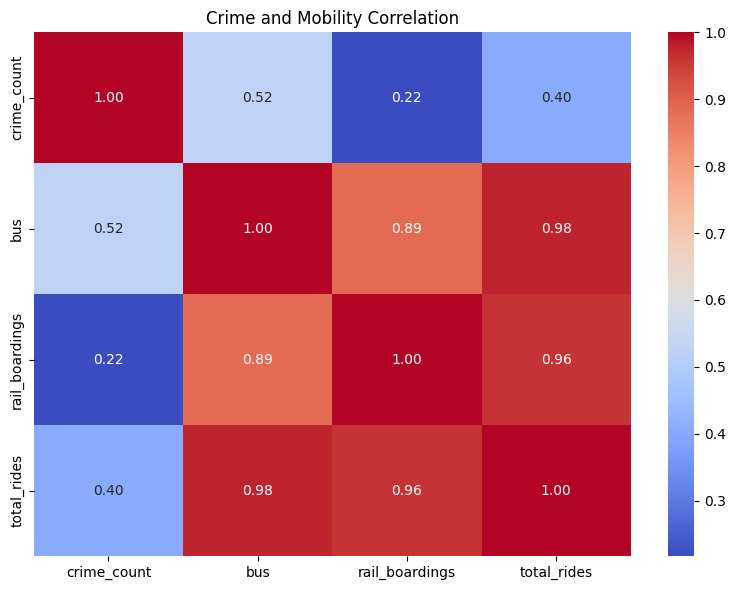

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Crime and Mobility Correlation')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "crime_mobility_correlation.png"),
            dpi=300, bbox_inches="tight")

plt.show()

In [8]:
# Crime vs Bus = 0.52 --> Moderate positive correlation
# Crime vs Rail = 0.22 --> Weak positive correlation
# Crime vs Total Rides = 0.40 --> Moderate positive correlation

In [10]:
# Pre-COVID , COVID and Post-COVID Periods

daily['year'] = daily['date'].dt.year

conditions = [
    daily['year'] <= 2019,
    daily['year'].between(2020, 2021),
    daily['year'] >= 2022
]

choices = ['Pre-COVID','COVID','Post-COVID']

daily['period'] = np.select(conditions,choices,default='Unknown')

In [11]:
period_stats = daily.groupby('period').agg(
    avg_daily_crime=('crime_count', 'mean'),
    avg_daily_rides=('total_rides', 'mean'),
    avg_crime_per_1000=('crime_per_1000_rides', 'mean')
).reset_index()

print(period_stats)

       period  avg_daily_crime  avg_daily_rides  avg_crime_per_1000
0       COVID       577.749658     5.382768e+05            1.312996
1  Post-COVID       689.398630     7.160073e+05            1.044723
2   Pre-COVID      1015.284911     1.368761e+06            0.827655


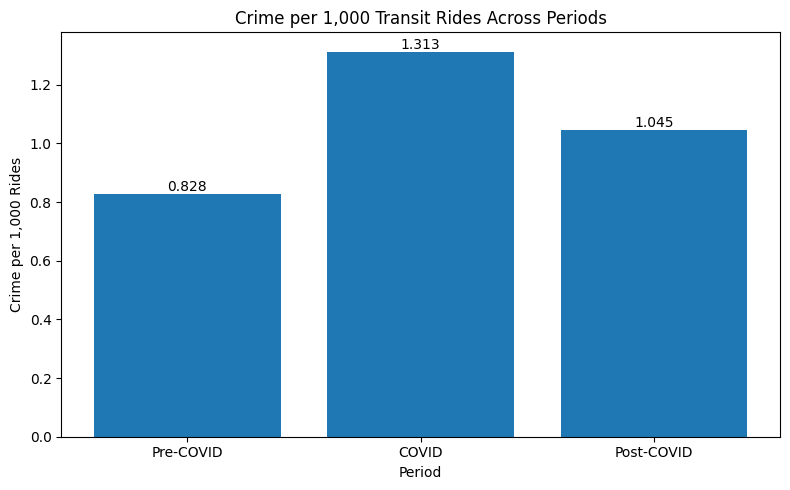

In [19]:
import matplotlib.pyplot as plt

# Assuming period_stats already exists

period_order = ['Pre-COVID', 'COVID', 'Post-COVID']

plot_data = period_stats.set_index('period').loc[period_order].reset_index()

plt.figure(figsize=(8,5))

bars = plt.bar(
    plot_data['period'],
    plot_data['avg_crime_per_1000'],
)

plt.title('Crime per 1,000 Transit Rides Across Periods')
plt.xlabel('Period')
plt.ylabel('Crime per 1,000 Rides')

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(save_dir, "crime_per_1000_rides_periods.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
""""
Although the total number of crimes declined during COIVD transit ridership experienced a much sharper decline.
Consequently the crime rate relative to transit usage increased from 0.82 to 1.313 per 10000 reides/
This means that crime didi not decrease proportionally with mobility reductions.


"""

'"\nAlthough the total number of crimes declined during COIVD transit ridership experienced a much sharper decline.\nConsequently the crime rate relative to transit usage increased from 0.82 to 1.313 per 10000 reides/\nThis means that crime didi not decrease proportionally with mobility reductions.\n\n\n'

In [15]:
daily['year'] = daily['date'].dt.year

covid_check = daily.groupby('period').agg(total_crimes=('crime_count','sum'), total_rides=('total_rides','sum'))

covid_check['crime_per_1000'] = (covid_check['total_crimes'] / covid_check['total_rides']) * 1000

print(covid_check)

            total_crimes  total_rides  crime_per_1000
period                                               
COVID             422335    393480361        1.073332
Post-COVID        503261    522685308        0.962837
Pre-COVID        7045062   9497835445        0.741754


In [16]:
# Annual Crime and Transit 

annual = daily.groupby('year').agg(
    crime_count=('crime_count', 'sum'),
    total_rides=('total_rides', 'sum')
).reset_index()

print(annual.head())


   year  crime_count  total_rides
0  2001       483413    483405757
1  2002       479810    483701088
2  2003       475979    472940755
3  2004       469416    472747184
4  2005       453779    490003697


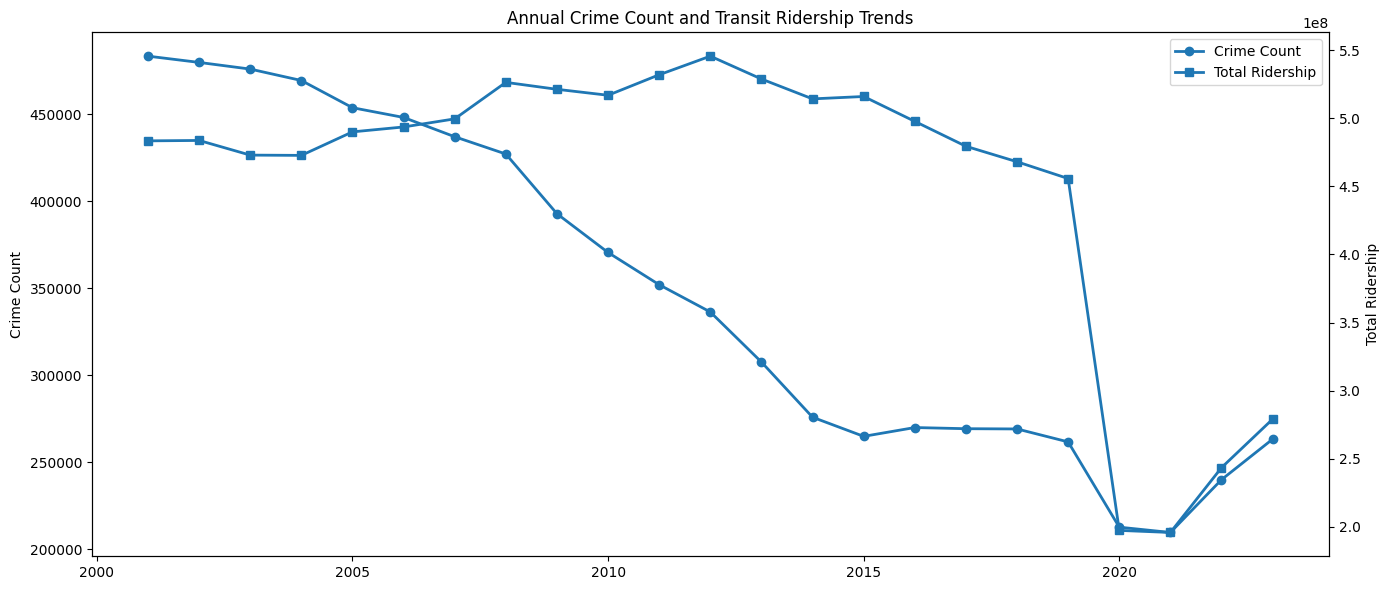

In [20]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Crime line
line1 = ax1.plot(
    annual['year'],
    annual['crime_count'],
    marker='o',
    linewidth=2,
    label='Crime Count'
)

ax1.set_ylabel('Crime Count')

# Second axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    annual['year'],
    annual['total_rides'],
    marker='s',
    linewidth=2,
    label='Total Ridership'
)

ax2.set_ylabel('Total Ridership')

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc='upper right')

plt.title('Annual Crime Count and Transit Ridership Trends')
plt.xlabel('Year')

plt.tight_layout()

plt.savefig(
    os.path.join(save_dir, "annual_crime_transit_trend.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
""" 
The annual trend analysis demonstrates that both crime and transit ridership experienced substantial declines during the COVID period
Then after it began to recover 
This parallel movement supports the hypothesis that mobility is an important contextual factor influencing crime occurrence.

"""

' \nThe annual trend analysis demonstrates that both crime and transit ridership experienced substantial declines during the COVID period\nThen after it began to recover \nThis parallel movement supports the hypothesis that mobility is an important contextual factor influencing crime occurrence.\n\n'

In [18]:
corr_table = pd.DataFrame({
    'Mobility Measure': ['Bus Ridership', 'Rail Ridership','Total Ridership' ],
    'Correlation With Crime': [
        daily['crime_count'].corr(daily['bus']),
        daily['crime_count'].corr(daily['rail_boardings']),
        daily['crime_count'].corr(daily['total_rides'])
    ]
})

corr_table['Correlation With Crime'] = (corr_table['Correlation With Crime'].round(3))

print(corr_table)

  Mobility Measure  Correlation With Crime
0    Bus Ridership                   0.524
1   Rail Ridership                   0.217
2  Total Ridership                   0.401
